In [ ]:
#Load libraries, actual loan histories, data set for prediction, and models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import pickle
import os
oos_df_pred = pd.read_csv('~/Prepayment_Analysis_Data/prediction_df_oos.csv')
oos_df_true= pd.read_csv(os.path.expanduser('~/Prepayment_Analysis_Data/mort_for_testing.csv'))
path1 = os.path.expanduser('~/Prepayment_Analysis_Data/cloglog_model_results_slim.pkl')
path2 = os.path.expanduser('~/Prepayment_Analysis_Data/best_boost_model.pkl')
log_model = joblib.load(path1)
boost_model = joblib.load(path2)

In [ ]:
#Scale data consistently with estimation data seet and get oos predictions for the boost model
scaler_path = os.path.expanduser('~/Prepayment_Analysis_Data/scaler.pkl')
scaler = joblib.load(scaler_path)

X_train_scaled = scaler.transform(X)

X_train_scaled = X_train_scaled.astype('float32')
boost_pred = boost_model.predict_proba(X_train_scaled)[:, 1]  

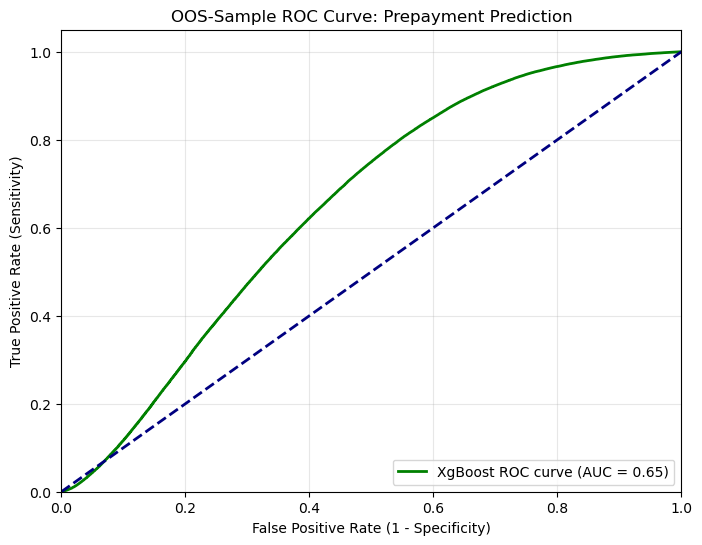

In [14]:
#Calculate the in-sample ROC values
fpr_boost, tpr_boost, thresholds_boost = roc_curve(y, boost_pred)
roc_auc_boost = roc_auc_score(y, boost_pred)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_boost, tpr_boost, color='green', lw=2, label=f'XgBoost ROC curve (AUC = {roc_auc_boost:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('OOS-Sample ROC Curve: Prepayment Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_oos.png", bbox_inches="tight")
plt.show()

In [6]:
#Get actual cumulative prepayment rates by DATE_NOW
#Calculate original UPB
oos_df_true = oos_df_true[pd.to_datetime(oos_df_true['DATE_NOW']) < pd.Timestamp('2025-02-01')].copy()
start_upb= oos_df_true[['LOAN_ID', 'ORIG_UPB']].drop_duplicates().set_index('LOAN_ID').sum().values[0]

oos_df_true['PREPAID_UPB'] = oos_df_true['PREPAY_FLAG'] * oos_df_true['ORIG_UPB']*oos_df_true['UPB_MULT']
cum_prepay = oos_df_true.groupby('DATE_NOW')['PREPAID_UPB'].sum().cumsum()/start_upb

In [ ]:
#get predicted cumulative prepayment rates by DATE_NOW based on prediction data set
X_pred = oos_df_pred[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
X_pred1= sm.add_constant(X_pred)
oos_df_pred['PREDICTED_PREPAY_PROB'] = log_model.predict(X_pred1)
oos_df_pred['STAY_PROB'] = 1 - oos_df_pred['PREDICTED_PREPAY_PROB']

# 2. Ensure the data is ordered by loan and time
oos_df_pred = oos_df_pred.sort_values(['LOAN_ID', 'LOAN_AGE'])

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
oos_df_pred['CUM_STAY_PROB'] = oos_df_pred.groupby('LOAN_ID')['STAY_PROB'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
oos_df_pred['LAG_PROD_SURVIVAL'] = (
    oos_df_pred.groupby('LOAN_ID')['CUM_STAY_PROB']
    .shift(1, fill_value=1.0)
)
oos_df_pred.drop(columns=['STAY_PROB', 'CUM_STAY_PROB'], inplace=True)
oos_df_pred['EXPECTED_PREPAID_UPB'] = oos_df_pred['ORIG_UPB'] * oos_df_pred['UPB_MULT']  * (oos_df_pred['LAG_PROD_SURVIVAL']) * oos_df_pred['PREDICTED_PREPAY_PROB']
agg_expected_prepay = oos_df_pred.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB'].sum().cumsum()/start_upb

In [8]:
#get predicted cumulative prepayment rates by DATE_NOW
X_pred = oos_df_pred[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]

X_pred_scaled = scaler.transform(X_pred)
X_pred_scaled = X_pred_scaled.astype('float32')
y_prob_boost = boost_model.predict_proba(X_pred_scaled)[:, 1] 
# 1. Calculate the 'stay' probability for each specific month
oos_df_pred['PREDICTED_PREPAY_PROB_BOOST'] = y_prob_boost
oos_df_pred['STAY_PROB_BOOST'] = 1 - oos_df_pred['PREDICTED_PREPAY_PROB_BOOST']

# 2. Ensure the data is ordered by loan and time
oos_df_pred = oos_df_pred.sort_values(['LOAN_ID', 'LOAN_AGE'])

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
oos_df_pred['CUM_STAY_PROB_BOOST'] = oos_df_pred.groupby('LOAN_ID')['STAY_PROB_BOOST'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
oos_df_pred['LAG_PROD_SURVIVAL_BOOST'] = (
    oos_df_pred.groupby('LOAN_ID')['CUM_STAY_PROB_BOOST']
    .shift(1, fill_value=1.0)
)
oos_df_pred.drop(columns=['STAY_PROB_BOOST', 'CUM_STAY_PROB_BOOST'], inplace=True)
oos_df_pred['EXPECTED_PREPAID_UPB_BOOST'] = oos_df_pred['ORIG_UPB'] * oos_df_pred['UPB_MULT']  * (oos_df_pred['LAG_PROD_SURVIVAL_BOOST']) * oos_df_pred['PREDICTED_PREPAY_PROB_BOOST']
agg_expected_prepay_boost = oos_df_pred.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB_BOOST'].sum().cumsum()/start_upb


In [9]:
cum_prepay_df= pd.DataFrame({'DATE_NOW': cum_prepay.index, 'CUM_PREPAY': cum_prepay.values})
cum_prepay_df['DATE_NOW'] = pd.to_datetime(cum_prepay_df['DATE_NOW'])
agg_expect_prepay_boost_df = pd.DataFrame({'DATE_NOW': agg_expected_prepay_boost.index, 'BOOST_CUM_PREPAY': agg_expected_prepay_boost.values})
agg_expect_prepay_boost_df['DATE_NOW'] = pd.to_datetime(agg_expect_prepay_boost_df['DATE_NOW'])         
cum_prepay_df=pd.merge(cum_prepay_df, agg_expect_prepay_boost_df, on='DATE_NOW', how='left')


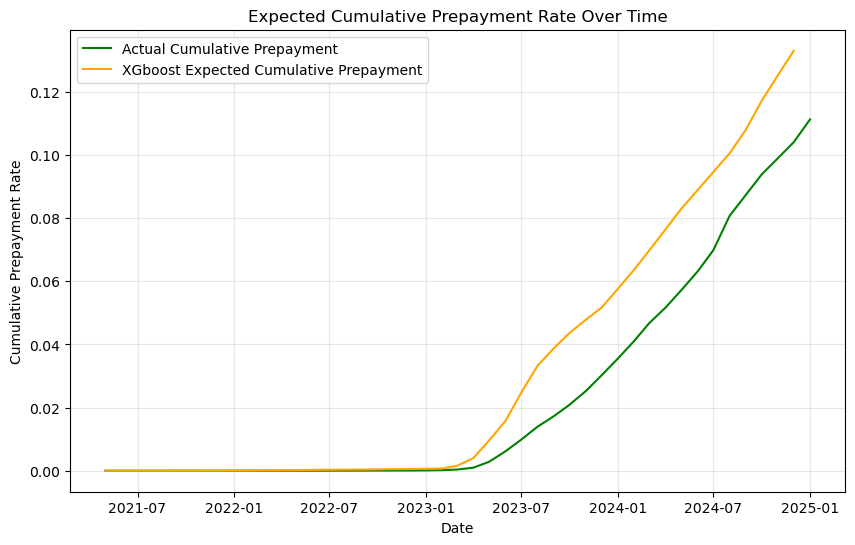

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(cum_prepay_df['DATE_NOW'], cum_prepay_df['CUM_PREPAY'], label='Actual Cumulative Prepayment', color='Green')
plt.plot(cum_prepay_df['DATE_NOW'], cum_prepay_df['BOOST_CUM_PREPAY'], label='XGboost Expected Cumulative Prepayment', color='Orange')
plt.xlabel('Date')
plt.ylabel('Cumulative Prepayment Rate')
plt.title('Expected Cumulative Prepayment Rate Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("ppay_oos.png", bbox_inches="tight")
plt.show()